# 🎓 에이전트 — 설계 & 기초 구축

## AI Language Learning Partner — **LinguaLoop (말문)**

## 🧩 Step 1. 에이전트 설계

### 1) 이름
**LinguaLoop (말문)**
표현이 *말문이 트이도록*, `Input → Analysis → Role Play → Feedback → Review` 루프를 도는 언어 학습 파트너.

### 2) 목적 — 어떤 문제를 해결하나?
외국어 영상을 보며 표현을 정리해도 **실제로 써볼 기회가 없어 금방 잊어버린다.**
LinguaLoop은 학습을 *입력 중심*에서 *출력 중심*으로 바꾼다.

- **입력**: 사용자가 모국어·학습 언어·유튜브 영상 선택
- **처리**: 자막에서 회화용 핵심 표현을 뽑아 퀴즈로 각인 → AI 파트너와의 실제 대화에서 그 표현을 **쓰도록 유도**
- **출력**: 표현 사용 여부를 채점해 피드백하고, 못 쓴/틀린 표현을 **복습 리스트**로 정리

### 3) 핵심 기능 (최소 3가지)
1. **표현 추출 (Analysis)** — 자막에서 회화용 핵심 표현 5~10개를 **뜻·예문**과 함께 추출
2. **퀴즈 생성 (Quiz)** — 추출한 표현으로 빈칸/의미 확인 퀴즈 자동 생성
3. **역할극 대화 파트너 (Role Play)** — 상황별 페르소나(연인·바리스타·친구·면접관 등)로 대화하며 학습 표현 사용을 유도
4. **피드백 & 복습 (Feedback / Review)** — 대화 중 표현 사용 여부를 채점하고, 미사용·오류 표현을 복습 리스트로 구성

### 4) 그래프 구조 — 노드와 엣지 다이어그램
- **선형 흐름**: 표현 추출 → 퀴즈 → 역할극 → 피드백 → 복습
- **조건부 루프(엣지)**: `roleplay_partner` 는 대화 턴이 `max_turns` 에 도달할 때까지 자기 자신으로 순환하고, 도달하면 `give_feedback` 로 진행

![](images/flowchart.png)

## 🛠️ Step 2. 기초 구축


### 2-1. 샘플 입력 & mock 데이터

데모에서는 **영어 카페 스몰토크 영상**의 자막을 예시 입력으로 사용합니다.
(모국어=한국어, 학습 언어=English)

In [6]:
# 예시 자막 (유튜브 Data API / Whisper로 받아올 자리)
SAMPLE_TRANSCRIPT = """
Hi there! Welcome. What can I get for you today?
I'll have a medium latte, please.
Sure. Would you like it hot or iced?
Iced, please. Could you make it less sweet?
Of course. Is that for here or to go?
To go, thanks. Anything else?
No, that's all.
Okay, that comes to four fifty. Have a great day!
"""

# ---- mock 응답 (키가 없을 때 노드가 반환하는 값) ----
MOCK_EXPRESSIONS = [
    {"expression": "I'll have ...",        "meaning": "~로 할게요 (주문)",       "example": "I'll have a medium latte, please."},
    {"expression": "Could you make it ...?","meaning": "~하게 해주실 수 있나요?",   "example": "Could you make it less sweet?"},
    {"expression": "for here or to go",     "meaning": "매장/포장 여부",          "example": "Is that for here or to go?"},
    {"expression": "Anything else?",        "meaning": "더 필요하신 거 있나요?",   "example": "No, that's all."},
    {"expression": "that comes to ...",     "meaning": "합계가 ~입니다",          "example": "That comes to four fifty."},
]

MOCK_QUIZ = [
    {"question": "주문할 때: '___ a medium latte, please.'", "answer": "I'll have"},
    {"question": "덜 달게: 'Could you ___ it less sweet?'",  "answer": "make"},
    {"question": "포장 확인: 'Is that for here or ___?'",     "answer": "to go"},
]

# 역할극에서 파트너(바리스타)가 내놓을 mock 대사 (턴 순서대로)
MOCK_PARTNER_REPLIES = [
    "Sure! Would you like it hot or iced?",
    "One iced latte coming up. For here or to go?",
    "Great — that comes to four fifty. Anything else?",
]

# 데모용 가상 학습자 발화 (실제 서비스에서는 UI 사용자 입력으로 대체)
SIMULATED_LEARNER = [
    "Hi, I'll have a latte, please.",
    "Could you make it iced?",
    "To go, thanks.",
]

### 2-2. State 정의 — `LearningState`

In [7]:
from pydantic import BaseModel, Field


class LearningState(BaseModel):
    native_language: str                     # 모국어
    target_language: str                     # 학습 언어
    transcript: str                          # 입력 자막
    key_expressions: List[Dict] = Field(default_factory=list)   # ① 추출된 핵심 표현
    quiz: List[Dict] = Field(default_factory=list)              # ② 생성된 퀴즈
    messages: Annotated[list, add_messages] = Field(default_factory=list)  # ③ 대화 기록 (누적)
    turn_count: int = 0                       # 현재 대화 턴 수
    max_turns: int = 3                        # 종료 조건
    feedback: str = ""                        # ④ 피드백 텍스트
    review_list: List[Dict] = Field(default_factory=list)       # ⑤ 복습 리스트
    stage: str = "start"                      # 진행 단계 표시

### 2-3. 노드 함수 구현 (5개)


In [8]:
# ① 자막 → 핵심 표현 추출
def extract_expressions(state: LearningState) -> dict:
    system = (
        "You are a language coach. Extract 5-10 useful CONVERSATIONAL expressions "
        "from the transcript. Return a JSON list of "
        '{"expression","meaning","example"}. Meaning must be in the learner\'s native language.'
    )
    user = (
        f"Native language: {state.native_language}\n"
        f"Target language: {state.target_language}\n"
        f"Transcript:\n{state.transcript}"
    )
    exprs = llm_json(system, user, mock=MOCK_EXPRESSIONS)
    return {"key_expressions": exprs, "stage": "quiz"}


# ② 표현 → 퀴즈 생성
def generate_quiz(state: LearningState) -> dict:
    system = (
        "Create a short fill-in-the-blank quiz (3-5 items) that checks the given "
        'expressions. Return a JSON list of {"question","answer"}.'
    )
    user = "Expressions:\n" + json.dumps(state.key_expressions, ensure_ascii=False)
    quiz = llm_json(system, user, mock=MOCK_QUIZ)
    return {"quiz": quiz, "stage": "roleplay"}


# ③ 역할극 대화 파트너 (표현 사용 유도) — 조건부로 자기 자신에 순환
def roleplay_partner(state: LearningState) -> dict:
    turn = state.turn_count

    # 데모용: 가상 학습자 발화. 실제 서비스에서는 UI 사용자 입력으로 대체.
    learner_utt = (
        SIMULATED_LEARNER[turn] if turn < len(SIMULATED_LEARNER) else "Thanks, bye!"
    )

    targets = ", ".join(e["expression"] for e in state.key_expressions)
    system = SystemMessage(content=(
        "You are a friendly barista. Roleplay a short cafe conversation. "
        f"Gently encourage the learner to use these expressions: {targets}. "
        "Keep each reply to one or two sentences."
    ))
    convo = [system] + list(state.messages) + [HumanMessage(content=learner_utt)]
    reply = llm_text(convo, mock=MOCK_PARTNER_REPLIES[min(turn, len(MOCK_PARTNER_REPLIES) - 1)])

    return {
        "messages": [HumanMessage(content=learner_utt), AIMessage(content=reply)],
        "turn_count": turn + 1,
        "stage": "roleplay",
    }


# 조건부 엣지용 라우터: 턴이 다 차면 피드백으로, 아니면 대화 계속
def route_after_roleplay(state: LearningState) -> str:
    if state.turn_count >= state.max_turns:
        return "give_feedback"
    return "roleplay_partner"


# ④ 대화 후 피드백 — 학습 표현을 실제로 썼는지 채점
def give_feedback(state: LearningState) -> dict:
    learner_text = " ".join(
        m.content for m in state.messages if isinstance(m, HumanMessage)
    ).lower()

    used, missed = [], []
    for e in state.key_expressions:
        head = e["expression"].split(" ...")[0].split(" or ")[0].strip().lower()
        (used if head and head in learner_text else missed).append(e)

    lines = [f"✅ 사용한 표현 {len(used)}개 / ❌ 미사용 {len(missed)}개"]
    if used:
        lines.append("잘 쓴 표현: " + ", ".join(e["expression"] for e in used))
    if missed:
        lines.append("다음엔 이 표현도 써보세요: " + ", ".join(e["expression"] for e in missed))
    feedback = "\n".join(lines)

    return {"feedback": feedback, "review_list": missed, "stage": "review"}


# ⑤ 복습 리스트 구성 (간단한 간격 반복 스케줄 부여)
def build_review(state: LearningState) -> dict:
    review = []
    for i, e in enumerate(state.review_list):
        review.append({
            "expression": e["expression"],
            "meaning": e["meaning"],
            "example": e["example"],
            "review_after_days": [1, 3, 7][i % 3],  # 간단한 복습 주기
        })
    return {"review_list": review, "stage": "done"}

### 2-4. 그래프 연결 & compile

`START → 표현추출 → 퀴즈 → 역할극(조건부 루프) → 피드백 → 복습 → END`

In [9]:
builder = StateGraph(LearningState)

# 노드 등록
builder.add_node("extract_expressions", extract_expressions)
builder.add_node("generate_quiz", generate_quiz)
builder.add_node("roleplay_partner", roleplay_partner)
builder.add_node("give_feedback", give_feedback)
builder.add_node("build_review", build_review)

# 엣지 연결
builder.add_edge(START, "extract_expressions")
builder.add_edge("extract_expressions", "generate_quiz")
builder.add_edge("generate_quiz", "roleplay_partner")
builder.add_conditional_edges(
    "roleplay_partner",
    route_after_roleplay,
    {
        "roleplay_partner": "roleplay_partner",  # 대화 계속 (루프)
        "give_feedback": "give_feedback",        # 종료 후 피드백
    },
)
builder.add_edge("give_feedback", "build_review")
builder.add_edge("build_review", END)

app = builder.compile()
print("그래프 컴파일 완료 ✅")

그래프 컴파일 완료 ✅


### 2-5. 그래프 시각화

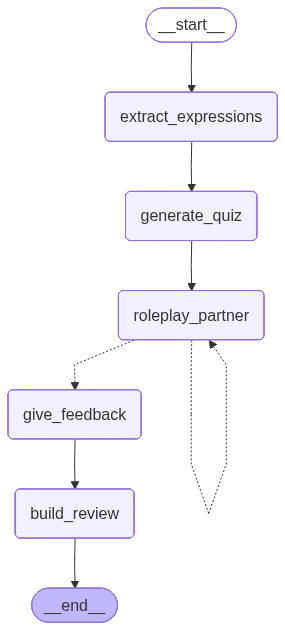

In [10]:
try:
    from IPython.display import Image, display
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print("(PNG 렌더 불가 — ASCII로 대체)\n")
    print(app.get_graph().draw_ascii())

### 2-6. End-to-End 실행 데모

전체 루프를 한 번에 실행합니다. (`max_turns=3`)

In [ ]:
init_state = LearningState(
    native_language="한국어",
    target_language="English",
    transcript=SAMPLE_TRANSCRIPT,
    max_turns=3,
)

result = app.invoke(init_state)

print("=" * 60)
print("① 추출된 핵심 표현")
print("=" * 60)
for e in result["key_expressions"]:
    print(f"- {e['expression']:<24} | {e['meaning']}")

print("\n" + "=" * 60)
print("② 퀴즈")
print("=" * 60)
for i, q in enumerate(result["quiz"], 1):
    print(f"Q{i}. {q['question']}  (정답: {q['answer']})")

print("\n" + "=" * 60)
print("③ 역할극 대화")
print("=" * 60)
for m in result["messages"]:
    who = "🧑 학습자" if isinstance(m, HumanMessage) else "🤖 파트너"
    print(f"{who}: {m.content}")

print("\n" + "=" * 60)
print("④ 피드백")
print("=" * 60)
print(result["feedback"])

print("\n" + "=" * 60)
print("⑤ 복습 리스트")
print("=" * 60)
for e in result["review_list"]:
    print(f"- {e['expression']:<24} | {e['review_after_days']}일 후 복습")

① 추출된 핵심 표현
- What can I get for you today? | 오늘 무엇을 도와드릴까요?
- I'll have...             | ...을 주세요.
- Would you like it hot or iced? | 따뜻하게 드릴까요, 아니면 얼음 넣어 드릴까요?
- Could you make it less sweet? | 조금 덜 단 것으로 만들어 주실 수 있나요?
- Is that for here or to go? | 여기서 드실 건가요, 아니면 가져가실 건가요?
- That's all.              | 그게 전부입니다.
- That comes to...         | ...입니다.
- Have a great day!        | 좋은 하루 되세요!

② 퀴즈
Q1. What can I get for you today?  (정답: 오늘 무엇을 도와드릴까요?)
Q2. I'll have...  (정답: ...을 주세요.)
Q3. Would you like it hot or iced?  (정답: 따뜻하게 드릴까요, 아니면 얼음 넣어 드릴까요?)
Q4. Could you make it less sweet?  (정답: 조금 덜 단 것으로 만들어 주실 수 있나요?)
Q5. Is that for here or to go?  (정답: 여기서 드실 건가요, 아니면 가져가실 건가요?)

③ 역할극 대화
🧑 학습자: Hi, I'll have a latte, please.
🤖 파트너: What can I get for you today? Would you like it hot or iced?
🧑 학습자: Could you make it iced?
🤖 파트너: Absolutely! Would you like it sweetened, or should I keep it as is?
🧑 학습자: To go, thanks.
🤖 파트너: Got it! Is that all for you today?

④ 피드백
✅ 사용한 표현 0개 / ❌ 미사

## 📌 정리 & 다음 단계

### 이번에 구현한 것
- 커스텀 **`LearningState`** (대화는 `add_messages` 리듀서로 누적)
- **5개의 작동하는 노드**와 **조건부 루프 엣지**로 코어 학습 흐름을 완성
- API 키 유무와 무관하게 **end-to-end로 실행**되는 LangGraph 에이전트

### 다음 버전에서 확장할 것
1. **실제 사용자 입력** — 데모의 가상 학습자(`SIMULATED_LEARNER`)를 `interrupt` 또는 UI 드라이버 루프로 교체
2. **세션 기억** — `checkpointer`(예: `MemorySaver`)로 사용자 수준·이력을 저장하고 부족한 표현을 반복 연습
3. **RAG 복습** — 복습 리스트를 ChromaDB에 적재해 표현 간 유사도 기반 추천
4. **입력 파이프라인** — YouTube Data API / Whisper로 실제 자막 수집
5. **멀티 페르소나** — 연인·친구·선생님·면접관 등 상황별 역할극 확장

> **배운 점:** 좋은 AI 학습 서비스의 핵심은 LLM 자체보다 *학습 흐름(Input→Analysis→Role Play→Feedback→Review)* 을 그래프로 설계하는 데 있다.
